# Classification with Torch Audio

# Prerequisites

- Run the following command: 
```bash
pip install -r requirements.txt
```

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa, librosa.display
import scipy
import torch
import torchaudio
from torchaudio import transforms
import math, random
import IPython.display as ipd
import os

# Data

`We will test on DS3500 Dataset`

#### DS3500 Dataset
**Basic Information of the Dataset**

- **Dataset Name**: Underwater Acoustic Target Radiated Noise Dataset (including the original ShipsEar dataset and the enhanced DS3500 dataset)
- **Dataset Version**: V1.0
- **Release Date**: July 2025 (based on the paper submission date)
- **Update Records**: First release, no updates yet
- **Source and Contributors**:
  - Original ShipsEar dataset: Collected along the Atlantic coast of Spain from 2012 to 2013
  - Enhanced DS3500 dataset: Generated by institutions such as the School of Marine Engineering and Technology, Sun Yat - sen University based on ray theory (Contributors: Peng Qian, Jingyi Wang, etc., Affiliations: Sun Yat - sen University, Shanghai Marine Electronic Equipment Research Institute, etc.)
  - Contact information: qianp@mail2.sysu.edu.cn
- **Related Paper**: *Multi - Task Mixture - of - Experts Model for Underwater Target Localization and Recognition* (DOI: 10.3390/1010000)

<div class= "alert alert-block alert-info">
    <b>Tip:</b> How to download the dataset?
</div>

**Steps**: 

1- Link : https://modelscope.cn/datasets/qianpeng897/DS3500

2- Go to `Files and Version`

3- Clone the repo or download maunaly

In [61]:
import os

data_path = "Datasets/raw/DS3500"

files = os.listdir(data_path)

# Extract unique categories from first two parts of filename
categories = set(["_".join(f.split("_")[:2]) for f in files if f.endswith(".wav")])

print("Unique Categories:")
for i, cat in enumerate(sorted(categories)):
    print(f"{i}- {cat}")



Unique Categories:
0- 0_0
1- 0_1
2- 0_2
3- 0_3
4- 0_4
5- 1_0
6- 1_1
7- 1_2
8- 2_0
9- 3_0
10- 3_1
11- 4_0


**What The paper Says is :**

That this dataset contains 5 types of ships, so we are going to reduce the categories to 5 classe

## Data visulization

* Samples rate: 22050
* No of channel: 1
     - mono sound


<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

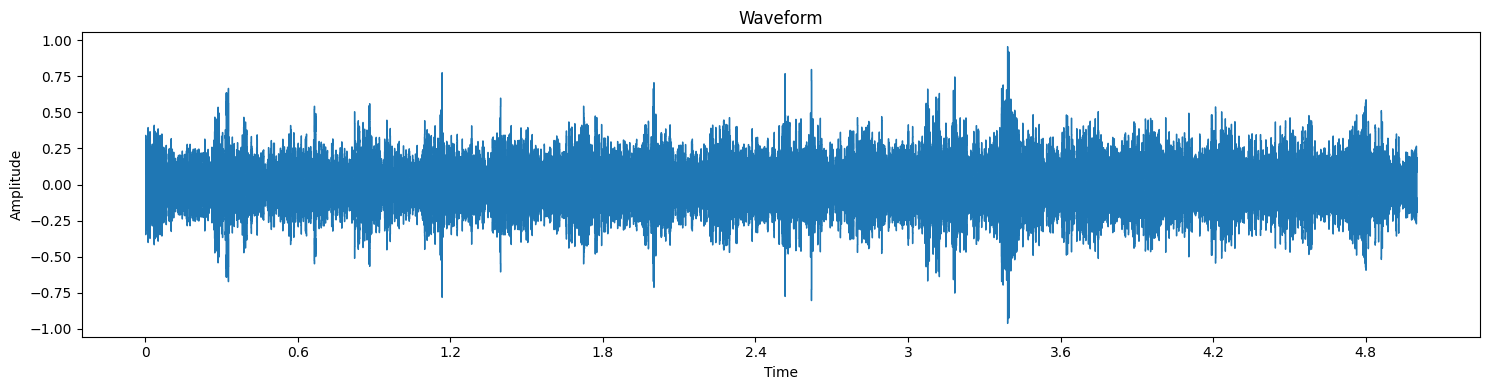

In [76]:
AUDIO_FILE = os.path.join(data_path, "0_0_1.wav")

sig, _ = torchaudio.load(AUDIO_FILE)
y, sr = librosa.load(AUDIO_FILE, duration=10)

fig, ax = plt.subplots(figsize=(15, 4), tight_layout=True)

librosa.display.waveshow(y, sr=sr, ax=ax)

# Details about the sound:
print(f"* Samples rate: {sr}")

if sig.shape[0] == 1:
    print(f"* No of channel: {sig.shape[0]}")
    print("     - mono sound")

plt.title("Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.plot



In [80]:
import IPython.display as ipd
print(AUDIO_FILE)
ipd.Audio(AUDIO_FILE)

Datasets/raw/DS3500/0_0_1.wav


### Spectrogram
Spectrograms are generated from sound signals using Fourier Transforms. A Fourier Transform decomposes the signal into its constituent frequencies and displays the amplitude of each frequency present in the signal.

A Spectrogram chops up the duration of the sound signal into smaller time segments and then applies the Fourier Transform to each segment, to determine the frequencies contained in that segment. It then combines the Fourier Transforms for all those segments into a single plot.

/var/folders/f7/d9r2cdsn7rjfqldbrf0y09dc0000gn/T/ipykernel_92262/3640903250.py:5: UserWarning: Trying to display complex-valued input. Showing magnitude instead.
  librosa.display.specshow(sgram, ax=ax)


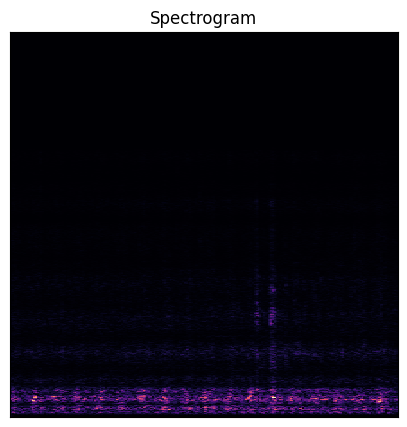

In [65]:
sgram = librosa.stft(y=y)
# sgram_db = librosa.amplitude_to_db(np.abs(sgram), ref=np.max)

fig, ax = plt.subplots(figsize=(5, 5))
librosa.display.specshow(sgram, ax=ax)

plt.title("Spectrogram")
plt.show()


unfortunately, when we display this spectrogram there isn’t much information for us to see. What happened to all those colorful spectrograms we used to see in Science class?

This happens because of the way humans perceive sound. Most of what we are able to hear are concentrated in a narrow range of frequencies and amplitudes. Let’s explore that first so we can figure out how to produce those lovely spectrograms.

### Mel Spectrograms

A Mel Spectrogram makes two important changes relative to a regular Spectrogram that plots Frequency vs Time.

- It uses the Mel Scale instead of Frequency on the y-axis.
- It uses the Decibel Scale instead of Amplitude to indicate colors.


For deep learning models, we usually use this rather than a simple Spectrogram.

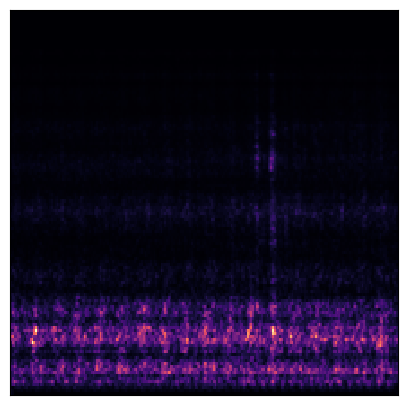

In [66]:
# Use Mel-Scale instead of raw frequency

fig, ax = plt.subplots(figsize=(5, 5))
sgram_mag, _ = librosa.magphase(sgram)
mel_scale_sgram = librosa.feature.melspectrogram(S=sgram_mag, sr=sr)
librosa.display.specshow(mel_scale_sgram, ax=ax)

plt.show()

This is better than before, but most of the spectrogram is still dark and not carrying enough useful information. So let’s modify it to use the Decibel Scale instead of Amplitude.

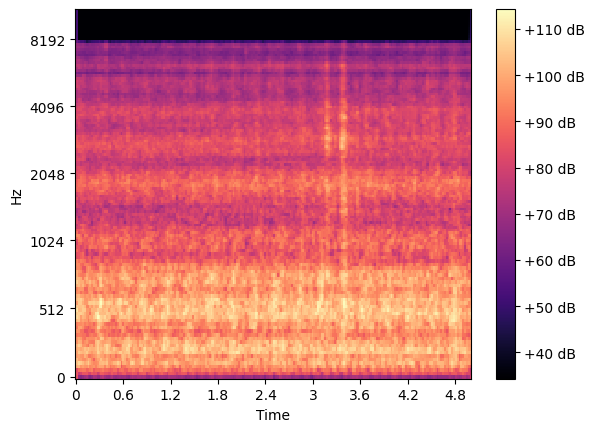

In [67]:
mel_sgram = librosa.amplitude_to_db(mel_scale_sgram, ref=np.min)
librosa.display.specshow(mel_sgram, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')

### Conclusion
This how we pre-process audio data and prepare Mel Spectrograms.

But before we can input them into deep learning models,
`we have to optimize them to obtain the best performance.`


# Audio Classification


<img src ="https://towardsdatascience.com/wp-content/uploads/2021/03/1S2USvKfzKXYjPM4hvoUcfg.png"/>

## Data preprocessing



1- Load Sound files.

2- Convert them to spectrograms.

3- Build **Base (CNN + Linear classifier)** model.

4- Evaluate the Base model.

### Data Loading 

I Will work with `Ships Ear` Dataset

In [57]:
shipear = "Datasets/raw/DS3500"
dataclasses = (os.listdir(shipear))
dataclasses
df = pd.DataFrame(sorted(dataclasses), columns=['file'])

df.head()

['2_0_350.wav',
 '1_1_9.wav',
 '1_0_166.wav',
 '2_0_436.wav',
 '1_0_172.wav',
 '2_0_422.wav',
 '2_0_344.wav',
 '3_1_256.wav',
 '3_1_46.wav',
 '3_1_242.wav',
 '3_1_52.wav',
 '2_0_378.wav',
 '1_1_15.wav',
 '2_0_393.wav',
 '2_0_9.wav',
 '0_1_15.wav',
 '2_0_387.wav',
 '3_1_295.wav',
 '3_1_85.wav',
 '0_1_29.wav',
 '3_1_281.wav',
 '3_1_91.wav',
 '2_0_634.wav',
 '2_0_152.wav',
 '2_0_146.wav',
 '2_0_620.wav',
 '2_0_608.wav',
 '0_2_93.wav',
 '0_2_87.wav',
 '1_2_78.wav',
 '2_0_191.wav',
 '2_0_185.wav',
 '0_2_78.wav',
 '2_0_813.wav',
 '1_2_44.wav',
 '4_0_223.wav',
 '0_2_50.wav',
 '0_2_44.wav',
 '1_2_50.wav',
 '2_0_807.wav',
 '2_0_740.wav',
 '3_0_12.wav',
 '3_1_108.wav',
 '2_0_12.wav',
 '2_0_754.wav',
 '3_1_120.wav',
 '1_0_82.wav',
 '3_1_134.wav',
 '1_0_96.wav',
 '2_0_768.wav',
 '2_0_783.wav',
 '1_0_69.wav',
 '2_0_797.wav',
 '1_0_41.wav',
 '1_0_55.wav',
 '0_0_41.wav',
 '2_0_224.wav',
 '2_0_542.wav',
 '2_0_556.wav',
 '2_0_230.wav',
 '3_0_119.wav',
 '4_0_196.wav',
 '3_0_131.wav',
 '2_0_218.wav',
 '4

In [34]:
df["class"] = df['file'].apply(lambda name: name[0])

# Correct the data type conversion
df['class'] = df['class'].astype('int32')
df.head()

,file,class
0,0_0_1.wav,0
1,0_0_10.wav,0
2,0_0_11.wav,0
3,0_0_12.wav,0
4,0_0_13.wav,0


In [82]:
def load_data(data_path: str, file_Column_name: str = "file", class_column_name: str = "class"):
    files = os.listdir(data_path)
    df = pd.DataFrame(sorted(dataclasses), columns=[file_Column_name])

    df[class_column_name] = df[file_Column_name].apply(lambda name: name[0])
    df[class_column_name] = df[class_column_name].astype('int32')
    df[file_Column_name] = df[file_Column_name].apply(lambda x: os.path.join(data_path, x))

    return df

df = load_data(shipear)

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2223 entries, 0 to 2222
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   file    2223 non-null   object
 1   class   2223 non-null   int32 
dtypes: int32(1), object(1)
memory usage: 26.2+ KB


In [84]:
df['class'].nunique()

5

In [85]:
df['class'].value_counts()

class
2    843
3    486
0    369
1    301
4    224
Name: count, dtype: int64

As we see now we have five classes in our dataset.
`Five Types of ships`

### Data Visulization

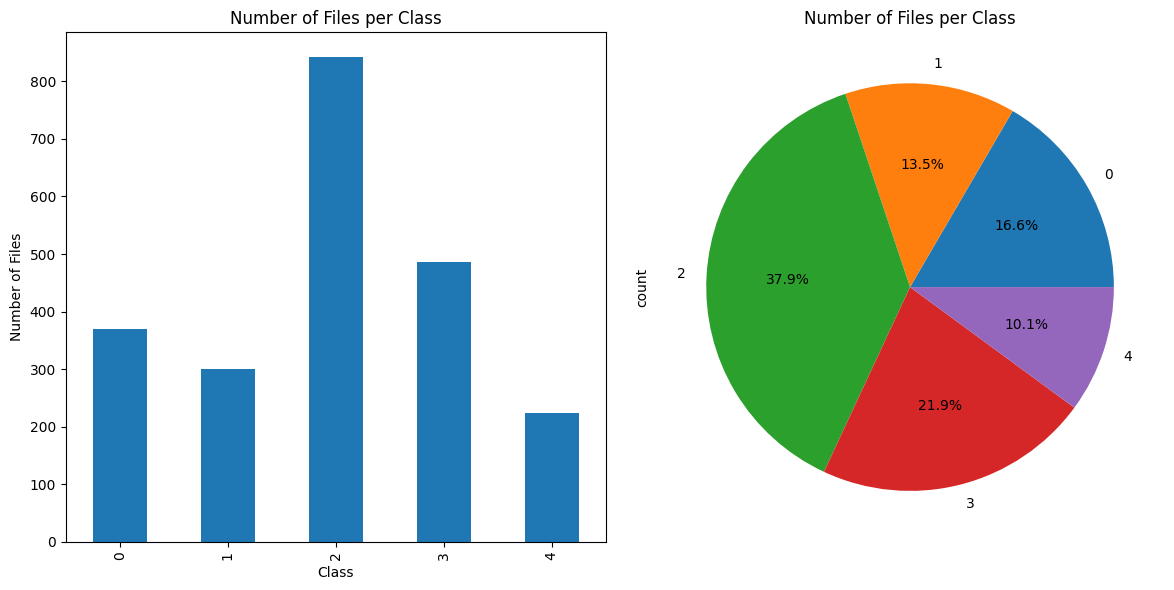

In [54]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Bar plot
df['class'].value_counts().sort_index().plot(kind="bar", ax=ax1, title='Number of Files per Class')
ax1.set_xlabel('Class')
ax1.set_ylabel('Number of Files')

# Pie chart
df['class'].value_counts().sort_index().plot(kind="pie", ax=ax2, title='Number of Files per Class', autopct='%1.1f%%')

plt.tight_layout()
plt.show()

we can see a dominance in class 2 

This Gives us the information we need for our training data.

## Audio Pre-processing

This training data with audio file paths cannot be input directly into the model.

We have to load the audio data from the file and process it so that it is in a format that the model expects.



### Transforms

<img src="https://towardsdatascience.com/wp-content/uploads/2021/03/1sHG9FrSI75fuX-ffGwZgHA.png">

<div class= "alert alert-block alert-warning">
    <b>[Note]:</b> In Covert to Mel Spectrogram step
</div>

**We are going to use `Linear Spectrogram`and not Mel spectrogram, why ?**

sticking to linear STFT spectrograms makes sense for underwater acoustics because:

- Mel scale compresses low frequencies (where ships/submarines live), while linear keeps all details.

- Marine sounds (engine hums, propeller cavitation, animal clicks) often have important fine structure across frequencies

In [86]:
# ----------------------------
# Audio Utility Class
# ----------------------------

class AudioUtil:
    """
    Utility class for handling audio preprocessing and augmentation.
    
    Provides helper methods to:
    - Load audio files
    - Convert channels (mono <-> stereo)
    - Resample to a target sampling rate
    - Pad or truncate audio to a fixed duration
    - Apply time-shift augmentations
    - Convert audio into spectrograms
    - Apply spectrogram augmentation (SpecAugment)
    """

    # ----------------------------
    # Read Audio
    # ----------------------------

    @staticmethod
    def open(audio_file):
        """
        Load an audio file.

        Args:
            audio_file (str): Path to the audio file.

        Returns:
            tuple: (sig, sr)
                sig (Tensor): Audio waveform [channels, time].
                sr (int): Sample rate.
        """
        sig, sr = torchaudio.load(audio_file)
        return (sig, sr)
    

    # ----------------------------
    # Channel Conversion
    # ----------------------------

    @staticmethod
    def rechannel(aud, new_channel):
        """
        Convert an audio signal to the desired number of channels.

        Args:
            aud (tuple): (sig, sr) input audio.
                sig (Tensor): Audio waveform [channels, time].
                sr (int): Sample rate.
            new_channel (int): Desired number of channels (1=mono, 2=stereo).

        Returns:
            tuple: (resig, sr) with updated channel configuration.
        """
        sig, sr = aud

        if (sig.shape[0] == new_channel):
            return aud
        
        if (new_channel == 1):
            # Stereo → Mono (keep only the first channel)
            resig = sig[:1, :]
        else:
            # Mono → Stereo (duplicate the channel)
            resig = torch.cat([sig, sig])
        
        return ((resig, sr))
    

    # ----------------------------
    # Resampling
    # ----------------------------

    @staticmethod
    def resample(aud, newsr):
        """
        Resample the audio to a new sample rate.

        Args:
            aud (tuple): (sig, sr) input audio.
                sig (Tensor): Audio waveform [channels, time].
                sr (int): Original sample rate.
            newsr (int): Target sample rate.

        Returns:
            tuple: (resig, newsr) resampled audio.
        """
        sig, sr = aud
        
        if (sr == newsr):
            return aud

        # Handle multi-channel case by resampling each channel independently
        num_channel = sig.shape[0]

        resig = torchaudio.transforms.Resample(sr, newsr)(sig[:1, :])
        
        if (num_channel >  1):
            retwo = torchaudio.transforms.Resample(sr, newsr)(sig[1:,:])
            resig = torch.cat([resig, retwo])

        return ((resig, newsr))
    

    # ----------------------------
    # Padding / Truncation
    # ----------------------------

    @staticmethod
    def pad_trucn(aud, max_ms):
        """
        Pad or truncate the audio signal to a fixed maximum duration.

        Args:
            aud (tuple): (sig, sr) input audio.
                sig (Tensor): Audio waveform [channels, time].
                sr (int): Sample rate.
            max_ms (int): Maximum duration in milliseconds.

        Returns:
            tuple: (sig, sr) with adjusted length.
        """
        sig, sr = aud
        num_channels, sig_len = sig.shape
        max_len = sr // 1000 * max_ms

        if (sig_len > max_len):
            # Truncate the signal
            sig = sig[:, :max_len]

        elif (sig_len < max_len):
            # Pad the signal randomly at beginning and/or end
            pad_begin_len = random.randint(0, max_len - sig_len)
            pad_end_len = max_len - sig_len - pad_begin_len

            # Zero padding
            pad_begin = torch.zeros((num_channels, pad_begin_len))
            pad_end = torch.zeros((num_channels, pad_end_len))

            sig = torch.cat((pad_begin, sig, pad_end), 1)
            
        return (sig, sr)


    # ----------------------------
    # Time Shifting (Augmentation)
    # ----------------------------

    @staticmethod
    def time_shift(aud, shift_limit=0.2):
        """
        Apply circular time-shift to the audio.

        Args:
            aud (tuple): (sig, sr) input audio.
            shift_limit (float): Maximum fraction of total length to shift.
                                 e.g., 0.2 = up to 20% shift.

        Returns:
            tuple: (shifted_sig, sr)
        """
        sig, sr = aud
        _, sig_len = sig.shape
        shift_amt = int(random.random() * shift_limit * sig_len)
        return (sig.roll(shift_amt), sr)
    

    @staticmethod
    def time_shift_zeropad(aud, shift_limit=0.1):
        """
        Apply time-shift with zero padding (non-circular).

        Args:
            aud (tuple): (sig, sr) input audio.
            shift_limit (float): Maximum fraction of total length to shift.
                                 Positive = shift right, Negative = shift left.

        Returns:
            tuple: (shifted_sig, sr)
        """
        sig, sr = aud
        _, sig_len = sig.shape
        shift_amt = int((2 * random.random() - 1) * shift_limit * sig_len)
        
        if (shift_amt > 0):
            pad = torch.zeros((sig.shape[0], shift_amt))
            sig = torch.cat((pad, sig[:, :-shift_amt]), dim=1)
        
        elif (shift_amt < 0):
            pad = torch.zeros((sig.shape[0], -shift_amt))
            sig = torch.cat((sig[:, -shift_amt:], pad), dim=1)
        
        return (sig, sr)


    @staticmethod
    def augment(aud, shift_limit=0.2):
        """
        Randomly choose an augmentation strategy (roll shift, zero-pad shift, or none).

        Args:
            aud (tuple): (sig, sr) input audio.
            shift_limit (float): Maximum fraction of total length to shift.

        Returns:
            tuple: (augmented_sig, sr)
        """
        sig, sr = aud
        choice = random.choice(["roll", "zero", "none"])

        if (choice == "roll"):
            sig, sr = AudioUtil.time_shift(aud, shift_limit=shift_limit)
        
        elif (choice == "zero"):
            sig, sr = AudioUtil.time_shift_zeropad(aud, shift_limit=shift_limit)

        return (sig, sr)


    # ----------------------------
    # Spectrogram Generation
    # ----------------------------

    @staticmethod
    def spectro_gram(aud, n_fft=1024, hop_len=None, win_len=None):
        """
        Generate a linear Short-Time Fourier Transform (STFT) spectrogram.

        Args:
            aud (tuple): (sig, sr) input audio.
                sig (Tensor): Audio waveform [channels, time].
                sr (int): Sample rate.
            n_fft (int): FFT window size. Default = 1024.
            hop_len (int): Hop length (stride) between windows. Default = n_fft // 4.
            win_len (int): Window size. Default = n_fft.

        Returns:
            Tensor: Spectrogram [channels, freq_bins, time_frames] in decibels.
        """
        sig, _ = aud
        top_db = 80

        # Compute linear spectrogram
        spec = transforms.Spectrogram(
            n_fft=n_fft,
            hop_length=hop_len,
            win_length=win_len,
            power=2.0
        )(sig)

        # Convert amplitude → decibels
        spec = transforms.AmplitudeToDB(top_db=top_db)(spec)

        return spec



    @staticmethod
    def mel_spectrogram(aud, n_mels=64, n_fft=1024, hop_len=None, win_len=None):
        """
        Generate a Mel Spectrogram from an audio signal.

        Args:
            aud (tuple): (sig, sr) input audio.
            n_mels (int): Number of Mel filter banks.
            n_fft (int): FFT window size.
            hop_len (int): Hop length (stride) between windows.

        Returns:
            Tensor: Mel Spectrogram [channels, n_mels, time_frames] in decibels.
        """
        sig, sr = aud
        top_db = 80

        # Create the Mel Spectrogram transform
        mel_spectrogram_transform = transforms.MelSpectrogram(
            sample_rate=sr,
            n_fft=n_fft,
            win_length=win_len,
            hop_length=hop_len,
            n_mels=n_mels,
            power=2.0
        )
        
        # Apply the transform
        spec = mel_spectrogram_transform(sig)

        # Convert amplitude to decibels
        spec = transforms.AmplitudeToDB(top_db=top_db)(spec)
        
        return spec


    # ----------------------------
    # Spectrogram Augmentation (SpecAugment)
    # ----------------------------

    @staticmethod
    def spectro_augment(spec, max_mask_pct=0.1, n_freq_masks=1, n_time_masks=1):
        """
        Apply SpecAugment to a spectrogram.

        Randomly masks sections in both frequency and time dimensions to improve
        model robustness against missing or corrupted features.

        Args:
            spec (Tensor): Input spectrogram [channels, freq_bins, time_frames].
            max_mask_pct (float): Maximum fraction of freq/time bins to mask.
            n_freq_masks (int): Number of frequency masks to apply.
            n_time_masks (int): Number of time masks to apply.

        Returns:
            Tensor: Augmented spectrogram of the same shape as input.
        """
        aug_spec = spec.clone()
        _, n_mels, n_steps = aug_spec.shape
        mask_value = aug_spec.mean()

        # Frequency masking
        freq_mask_param = int(max_mask_pct * n_mels)
        for _ in range(n_freq_masks):
            aug_spec = transforms.FrequencyMasking(freq_mask_param)(aug_spec)

        # Time masking
        time_mask_param = int(max_mask_pct * n_steps)
        for _ in range(n_time_masks):
            aug_spec = transforms.TimeMasking(time_mask_param)(aug_spec)

        return aug_spec


## Custom Data Loader 

**--- CONFIGURATION FOR DS3500 DATASET ---**

Based on the README file and the paper:
- Duration: 5 seconds
- Sample-rate: 16khz (16000)
- Channel: Mono


In [88]:
from torch.utils.data import Dataset

class SoundDS(Dataset):
    def __init__(self, df, is_train=True):
        self.df = df
        self.is_train = is_train

        # --- CONFIGURATION FOR DS3500 DATASET ---

        self.duration = 5000
        self.sr = 16000
        self.channel = 1
        
        
        # Augmentation parameters
        self.shift_pct = 0.2
        
        # Spectrogram parameters
        self.n_mels = 128
        self.n_fft = 1024
        self.hop_len = 512

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # --- 1. Get File Path and Class ID ---
        
        audio_file = self.df.loc[idx, 'filepath']
        class_id = self.df.loc[idx, 'ClassID']

        # --- 2. Load and Preprocess Audio ---
        aud = AudioUtil.open(audio_file)
        
        reaud = AudioUtil.resample(aud, self.sr)
        
        rechan = AudioUtil.rechannel(reaud, self.channel)
        
        dur_aud = AudioUtil.pad_trucn(rechan, self.duration)
        

        # --- 3. Apply Augmentations (only for training set) ---
        if self.is_train:
            dur_aud = AudioUtil.time_shift(dur_aud, self.shift_pct)

        # --- 4. Generate Mel Spectrogram ---
        sgram = AudioUtil.mel_spectrogram(
            dur_aud, 
            n_mels=self.n_mels, 
            n_fft=self.n_fft, 
            hop_len=self.hop_len
        )
        
        # --- 5. Apply Spectrogram Augmentation (only for training set) ---
        if self.is_train:
            # Apply SpecAugment
            sgram = AudioUtil.spectro_augment(
                sgram, max_mask_pct=0.1, n_freq_masks=2, n_time_masks=2
            )
            
        return sgram, class_id

## The Recommended Model by paper (MEG Framework)



The paper's primary model is called MEG (Multi-task, Multi-expert, Multi-gate) framework.

This is not a standard, off-the-shelf model like ResNet. It's a complex, custom architecture designed specifically for the dual tasks of classification (what kind of ship is it?) and localization (where is the ship?).

**What is it conceptually?**

`Think of it as a "team of specialist" models working together:`

- **Multi-task**: The model is trained to predict multiple things at once: the ClassID (a classification task) and the distance/depth (regression tasks).

- **Mixture-of-Experts (MoE)**: Instead of one giant model trying to learn everything, the MEG framework has several smaller "expert" networks (like individual CNNs). Each expert might become good at identifying ships in specific scenarios (e.g., one expert for close ships, another for far ships).

- **Multi-gate**: A "gating" network acts like a manager. For each audio input, it looks at the features and decides which "expert" is best suited for the job, assigning more weight to that expert's prediction.

-------------

## Base Model
- We don't need to implement the full meg framework. That would be very advanced at this early step.



CNN Model:

**Input**:

- Input tensor shape = [batch_size, 1, 128, 313]

    - `1`: number of input channels (grayscale, because spectrograms have 1 channel).

    - `128`: frequency bins (rows of the spectrogram).

    - `313`: time frames (columns of the spectrogram).


**Output**:


- For an input of 128×313:

    - After 1st pool: 128 → 64, 313 → 156

    - After 2nd pool: 64 → 32, 156 → 78

    - After 3rd pool: 32 → 16, 78 → 39

So final conv `output` = [batch_size, 64, 16, 39]


In [91]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
import numpy as np


class SimpleCnn(nn.Module):
    def __init__(self, num_classes = 5):
        super.__init__()

        # Input: (batch_size, 1, 128, 313) -> (Channels, Mel-bins, Time-frames)
        self.conv_layer = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Input to flattern = output of conv layer = [batch_size, 64, 16, 39]
        self.flatten = nn.Flatten()


        self.linear_layers == nn.Sequential(
            nn.Linear(in_features= 64*16*39, out_features=128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(in_features=128, out_features=num_classes)
        )

        def forward(self, x):
            x = self.conv_layers(x)
            x = self.flatten(x)
            x = self.linear_layers(x)
            return x

        

### Training and Evaluation Strategy (Paper)
The paper strongly suggests using a 5-fold cross-validation strategy. This is a robust way to evaluate the model. It means split the data into 5 equal parts ("folds"):

Train on folds 1, 2, 3, 4 and test on fold 5.

Train on folds 1, 2, 3, 5 and test on fold 4.

...and so on, until each fold has been used as the test set once.

This gives you a more reliable measure of model's performance than a single train/test split.

In [89]:
# Pre Dataloader (Based on the paper)
from sklearn.model_selection import StratifiedKFold


# Dataframe
df = load_data(shipear, file_Column_name="filepath", class_column_name="ClassID")



skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

df['fold'] = -1 

for fold_num, (train_idx, val_idx) in enumerate(skf.split(df, df['ClassID'])):
    df.loc[val_idx, 'fold'] = fold_num

print("\nFold assignments added to DataFrame:")
print(df.head())

print("\nNumber of samples in each fold:")
print(df['fold'].value_counts())


Fold assignments added to DataFrame:
                         filepath  ClassID  fold
0   Datasets/raw/DS3500/0_0_1.wav        0     4
1  Datasets/raw/DS3500/0_0_10.wav        0     0
2  Datasets/raw/DS3500/0_0_11.wav        0     0
3  Datasets/raw/DS3500/0_0_12.wav        0     4
4  Datasets/raw/DS3500/0_0_13.wav        0     0

Number of samples in each fold:
fold
0    445
1    445
2    445
4    444
3    444
Name: count, dtype: int64


In [ ]:
# Example:
for fold_to_validate in range(5):
    print(f"\n===== FOLD {fold_to_validate} =====")
    
    train_df = df[df['fold'] != fold_to_validate].reset_index(drop=True)
    val_df = df[df['fold'] == fold_to_validate].reset_index(drop=True)
    
    # --- Create PyTorch Datasets ---
    train_ds = SoundDS(df=train_df, is_train=True)
    val_ds = SoundDS(df=val_df, is_train=False)
    
    # --- Create DataLoaders ---
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
    

#### Training and Evaluation loop

In [90]:
from torch.utils.data import DataLoader
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Dataframe (Meta data)
df = load_data(shipear, file_Column_name="filepath", class_column_name="ClassID")

# Initilize 5-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store the accuracy of each fold
fold_accuracies = []

# Main Cross Validation Loop

for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['ClassID'])):
    print(f"\n===================== FOLD {fold + 1} / 5 =====================")

    # Create df for this fold
    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)


    # Create Datasets and DataLoaders 
    train_ds = SoundDS(df=train_df, is_train=True)
    val_ds = SoundDS(df=val_df, is_train=False)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)


    # Initialize Model, loss, and Optimizer
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    model = SimpleCnn().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(params=model.parameters(), lr = 0.001)

    num_epochs = 30

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        
        epoch_loss = running_loss / len(train_loader.dataset)

        # Validation loop for this fold
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        accuracy = 100 * correct / total
        print(f"Epoch {epoch+1}/{num_epochs} -> Loss: {epoch_loss:.4f}, Validation Accuracy: {accuracy:.2f}%")
    


    print(f"Fold {fold + 1} final accuracy: {accuracy:.2f}%")
    fold_accuracies.append(accuracy)



# --- Final Results ---
print("\n================= CROSS-VALIDATION COMPLETE =================")
mean_accuracy = np.mean(fold_accuracies)
std_accuracy = np.std(fold_accuracies)
print(f"Average Accuracy across 5 folds: {mean_accuracy:.2f}%")
print(f"Standard Deviation of Accuracy: {std_accuracy:.2f}%")


    


===== FOLD 0 =====

===== FOLD 1 =====

===== FOLD 2 =====

===== FOLD 3 =====

===== FOLD 4 =====
